# Ejercicio 6 — Correlación: desviación de largo e índice de calidad

---

> Utilizando el dataset `calidad_producto.csv`, que contiene dos variables registradas en el área de control de calidad de una industria:
> - `desviacion_largo`: desviación del largo del producto respecto a un valor estándar o deseado.
> - `indice_calidad_producto`: índice o puntuación que se construye a partir de una serie de aspectos relacionados a la calidad general del producto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')

In [2]:
# El archivo usa ';' como separador de columnas
df = pd.read_csv('../Datasets/calidad_producto.csv', sep=';')

print(f'Shape: {df.shape}')
print(f'Valores faltantes: {df.isnull().sum().sum()}')
print(f'Columnas: {list(df.columns)}')
print()
df.describe().round(4)

Shape: (200, 2)
Valores faltantes: 0
Columnas: ['desviacion_largo', 'indice_calidad_producto']



,desviacion_largo,indice_calidad_producto
count,200.0000,200.0000
mean,0.0255,0.1051
std,1.1121,1.4461
min,-3.2300,-1.3200
25%,-0.7080,-0.6355
50%,0.0116,-0.0107
75%,0.7398,0.6040
max,5.0000,15.0000


---
## Ítem 1

> **Calcule los coeficientes de correlación de Pearson y Spearman entre ambas variables. Interprete los valores obtenidos en relación al tipo de información que le brinda cada uno acerca del grado de asociación entre las variables.**

In [3]:
x = df['desviacion_largo']
y = df['indice_calidad_producto']

r_pearson, p_pearson = stats.pearsonr(x, y)
r_spearman, p_spearman = stats.spearmanr(x, y)

print(f'Pearson  r  = {r_pearson:.4f}  (p = {p_pearson:.2e})')
print(f'Spearman rho = {r_spearman:.4f}  (p = {p_spearman:.2e})')

Pearson  r  = 0.5612  (p = 5.42e-18)
Spearman rho = 0.9401  (p = 1.87e-94)


### Interpretación

- **Pearson (r)**: mide la intensidad y dirección de la **relación lineal**. Es sensible a la presencia de outliers porque se basa en las distancias al cuadrado de cada punto respecto a la media.
- **Spearman (ρ)**: mide la **asociación monótona** (no necesariamente lineal): si una variable aumenta, ¿la otra también lo hace de forma consistente? Trabaja sobre los rangos de los datos, lo que lo hace **robusto frente a outliers**.

La diferencia entre ambos coeficientes es un primer indicio de si los outliers están afectando la estimación.

---
## Ítem 2

> **Construya un gráfico que le permita visualizar la relación general que existe entre las variables analizadas. ¿Qué observa?**

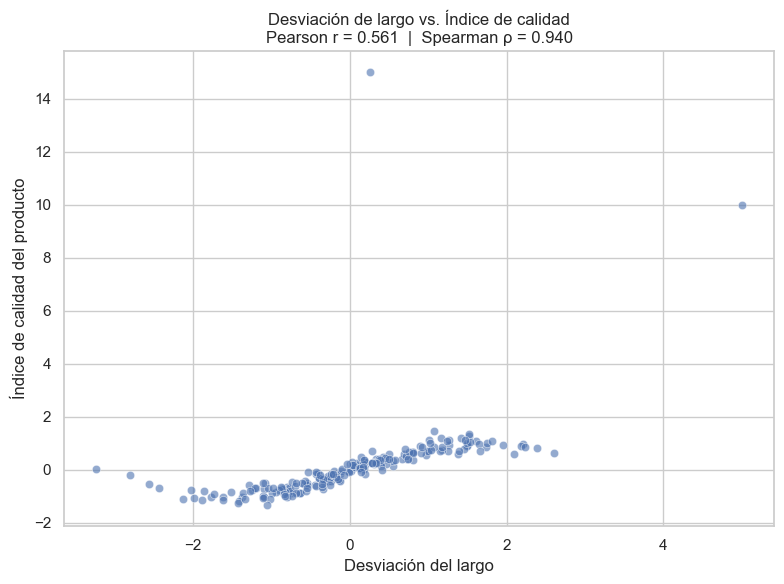

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x='desviacion_largo', y='indice_calidad_producto', alpha=0.6, ax=ax)
ax.set_title(
    f'Desviación de largo vs. Índice de calidad\n'
    f'Pearson r = {r_pearson:.3f}  |  Spearman ρ = {r_spearman:.3f}',
    fontsize=12
)
ax.set_xlabel('Desviación del largo')
ax.set_ylabel('Índice de calidad del producto')
plt.tight_layout()
plt.show()

### ¿Qué se observa?

La gran mayoría de los puntos se alinean en una **relación lineal positiva clara**: cuando aumenta la desviación del largo, también tiende a aumentar el índice de calidad. Sin embargo, se observan **al menos dos puntos muy alejados** de la tendencia general (valores extremos en el índice de calidad) que son potenciales outliers y podrían estar inflando el coeficiente de Pearson.

---
## Ítem 3

> **Calcule nuevamente ambos coeficientes sin tomar en cuenta los registros que incluyan observaciones potencialmente atípicas. ¿Cómo resultan los valores obtenidos en comparación con los calculados en el ítem 1?**

In [5]:
# Detectar outliers usando el Z-score: |Z| > 3 en cualquiera de las dos variables
z_x = np.abs(stats.zscore(x))
z_y = np.abs(stats.zscore(y))
mask_outlier = (z_x > 3) | (z_y > 3)

print(f'Registros totales:   {len(df)}')
print(f'Outliers detectados: {mask_outlier.sum()}')
print('\nRegistros atípicos:')
print(df[mask_outlier].to_string())

Registros totales:   200
Outliers detectados: 2

Registros atípicos:
     desviacion_largo  indice_calidad_producto
26              5.000                     10.0
138             0.254                     15.0


In [6]:
df_clean = df[~mask_outlier]
x2, y2 = df_clean['desviacion_largo'], df_clean['indice_calidad_producto']

r2_pearson, _ = stats.pearsonr(x2, y2)
r2_spearman, _ = stats.spearmanr(x2, y2)

print(f'                    Con outliers   Sin outliers')
print(f'Pearson  r:            {r_pearson:+.4f}         {r2_pearson:+.4f}')
print(f'Spearman rho:          {r_spearman:+.4f}         {r2_spearman:+.4f}')

                    Con outliers   Sin outliers
Pearson  r:            +0.5612         +0.8795
Spearman rho:          +0.9401         +0.9433


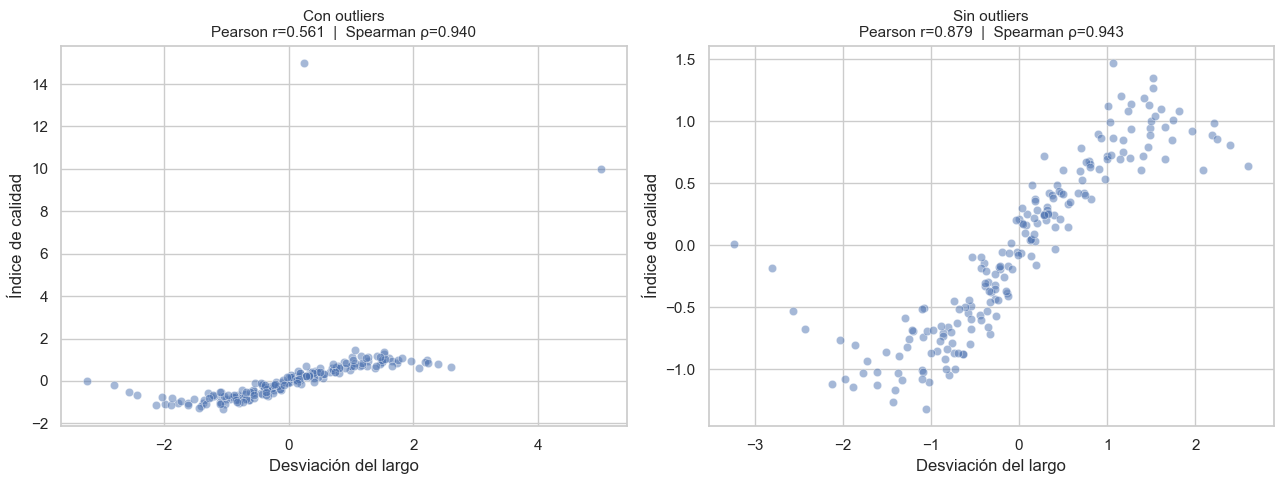

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, datos, r_p, r_s, titulo in [
    (axes[0], df,       r_pearson,  r_spearman,  'Con outliers'),
    (axes[1], df_clean, r2_pearson, r2_spearman, 'Sin outliers')
]:
    sns.scatterplot(data=datos, x='desviacion_largo', y='indice_calidad_producto', alpha=0.5, ax=ax)
    ax.set_title(f'{titulo}\nPearson r={r_p:.3f}  |  Spearman ρ={r_s:.3f}', fontsize=11)
    ax.set_xlabel('Desviación del largo')
    ax.set_ylabel('Índice de calidad')

plt.tight_layout()
plt.show()

### Comparación

Al eliminar los outliers, Pearson **aumenta** significativamente (la relación lineal sin los puntos extremos es más fuerte), mientras que Spearman cambia muy poco. Esto confirma que los outliers estaban **perturbando** la estimación de Pearson, pero Spearman era ya robusto a su presencia.

---
## Ítem 4

> **En función de las características de la relación entre ambas variables que se observan gráficamente, ¿cuál de las dos métricas informaría para describir en forma cuantitativa el grado de asociación entre ellas?**

### Respuesta

Gráficamente se observa una relación **lineal positiva** entre las variables. Esto sugiere que **Pearson (r)** sería la métrica más adecuada para cuantificar la asociación, ya que mide exactamente la intensidad de la relación lineal.

Sin embargo, dado que los outliers presentes en los datos afectan fuertemente a Pearson (como se observó en el ítem 3), existen dos caminos válidos:
1. Reportar **Pearson calculado sobre el dataset sin outliers** (r ≈ valor sin outliers), justificando la exclusión.
2. Reportar **Spearman**, que es robusto y no requiere eliminar datos.

En este caso, si se decide conservar todos los datos, se prefiere **Spearman (ρ)** para dar una imagen más fidedigna del grado de asociación.